Learned weights: w=[1. 1.], b=-1


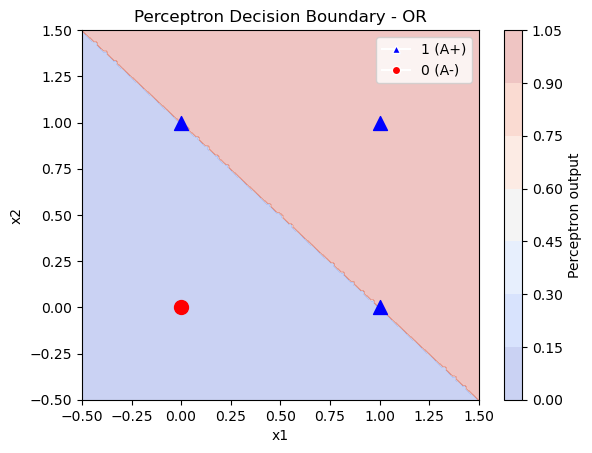

output([1 1]) = 1, expected 1
output([1 0]) = 1, expected 1
output([0 1]) = 1, expected 1
output([0 0]) = 0, expected 0


In [1]:
# numpy version

import numpy as np
import matplotlib.pyplot as plt

# Heaviside (works on scalars)
def H(z):
    return 1 if z >= 0 else 0

# Output using numpy dot product
def output(x, w, b):
    z = np.dot(w, x) + b
    return H(z)

# Learning with numpy + epochs
def p_learn(X, Y, w, b, eta, epochs):
    for _ in range(epochs):
        for x, y in zip(X, Y):
            z = np.dot(w, x) + b
            if y == 1 and z < 0:      # A+, predicted wrong
                w = w + eta * x
                b = b + eta
            elif y == 0 and z >= 0:   # A-, predicted wrong
                w = w - eta * x
                b = b - eta
    return w, b

# Plot decision boundary
def plot_boundary(w, b):
    # Create a grid of points
    x1_vals = np.linspace(-0.5, 1.5, 200)
    x2_vals = np.linspace(-0.5, 1.5, 200)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    
    # Compute perceptron output for every point in the grid
    Z = np.array([H(np.dot(w, np.array([x1, x2])) + b)
                  for x1, x2 in zip(X1.ravel(), X2.ravel())])
    Z = Z.reshape(X1.shape)
    
    plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
    plt.colorbar(label='Perceptron output')

# OR dataset as numpy arrays
X = np.array([[1,1],[1,0],[0,1],[0,0]])
Y_OR = [1, 1, 1, 0]

# Initial weights and bias
w = np.zeros(2)
b = 0

# Train
w, b = p_learn(X, Y_OR, w, b, eta=1, epochs=10)
print(f"Learned weights: w={w}, b={b}")

# Plot
plot_boundary(w, b)

# Overlay the data points
for x, y in zip(X, Y_OR):
    color = 'blue' if y == 1 else 'red'
    marker = '^' if y == 1 else 'o'
    plt.scatter(x[0], x[1], color=color, marker=marker, s=100, zorder=5)

plt.title("Perceptron Decision Boundary - OR")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='blue', label='1 (A+)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red',  label='0 (A-)')
])
plt.show()

# Verify outputs
for x, y in zip(X, Y_OR):
    print(f"output({x}) = {output(x, w, b)}, expected {y}")